# RRUFF Raman classification Project

## Getting the dataset ready

In [53]:
import os
import glob
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
%matplotlib inline

## Opening the file
to explore

In [54]:
with open("C:/Users/68pup/pythstuff/mycodes/ML/rruff_new/Actinolite__R040063-4__Raman__514__0-000____Raman_Data_Processed__c801aaca84d830ae65447fa8483e.txt","r") as f:
    for line in f:
        print(line.strip())

##NAMES=Actinolite
##RRUFFID=R040063
##IDEAL CHEMISTRY=[box]Ca_2_(Mg_4.5-2.5_Fe^2+^_0.5-2.5_)Si_8_O_22_(OH)_2_
##LOCALITY=Harford County, Maryland, USA
##OWNER=RRUFF
##SOURCE=University of Arizona Mineral Museum
##DESCRIPTION=Mass of green acicular to bladed crystals associated with talc and chlorite
##STATUS=The identification of this mineral has been confirmed by X-ray diffraction and chemical analysis
##URL=https://www.rruff.net/odr/rruff_sample/R040063
##MEASURED CHEMISTRY=(Ca_1.90_Na_0.06_Mn_0.04_)(Mg_4.35_Fe_0.65_)(Si_7.92_Al_0.08_)O_22_(OH)_2_
##PIN_ID=S00044
##ORIENTATION=Laser parallel to b* (0 1 0). Fiducial mark perpendicular to laser is parallel to c [0 0 1]
##DIFFRACTION SAMPLE DESCRIPTION=Powder, ~ 52% actinolite, 45% talc, 3% chlorite
##CELL PARAMETERS=a: 9.8387 b: 18.0744 c: 5.283 alpha: 90 beta: 104.708 gamma: 90 volume: 908.69 crystal system: monoclinic
##FILETYPE=Raman Processed
##RAMAN WAVELENGTH=514

146.865, 0.000
148.250, 0.627
149.635, 3.838
151.019, 97.367
152.

In [50]:
with open("C:/Users/68pup/pythstuff/mycodes/ML/rruff_new/Actinolite__R040063-4__Raman__514__0-000____Raman_Data_Processed__c801aaca84d830ae65447fa8483e.txt","r") as f:
    for line in f:
        if line.startswith("##") or line == "":
            continue
        print(line.strip())


146.865, 0.000
148.250, 0.627
149.635, 3.838
151.019, 97.367
152.403, 196.164
153.788, 437.289
155.171, 507.733
156.555, 532.424
157.939, 547.451
159.322, 553.050
160.705, 441.641
162.088, 321.887
163.470, 291.057
164.853, 258.958
166.235, 387.086
167.617, 660.090
168.998, 1210.735
170.380, 1883.859
171.761, 2996.341
173.142, 3959.099
174.523, 5069.067
175.904, 5559.270
177.284, 5426.411
178.664, 5010.116
180.044, 4009.485
181.424, 2920.444
182.803, 2086.803
184.183, 1519.634
185.562, 1012.000
186.940, 579.970
188.319, 437.608
189.698, 352.963
191.076, 151.065
192.454, 188.942
193.831, 139.617
195.209, 111.116
196.586, 89.459
197.963, 116.663
199.340, 123.735
200.717, 110.688
202.093, 178.530
203.470, 180.269
204.846, 376.242
206.221, 356.721
207.597, 580.536
208.972, 819.766
210.347, 1165.182
211.722, 1529.331
213.097, 1986.891
214.472, 2822.974
215.846, 3573.104
217.220, 4491.281
218.594, 5272.494
219.967, 5705.733
221.341, 5868.988
222.714, 5542.289
224.087, 5055.755
225.460, 4410.

### Defined a function to extract info from the file
the wavenumbers and intensities. It ignores the metadata starting with "##" and also any empty line. Also strips the data. Then in each iteration(where it is looking at one line at a time), it makes a python list "parts" storing in the values separated by the given delimiter, ie "," here. 
then we had defined empty lists for wavenumber and intensity info, so it in the loop when the parts lists has only two items in it for each line, the first part is the wavenumber that gets appended to the respective list with conversion to a float value, similarly the second item in the parts list is the intensity value which gets floated and appended in the respective list.


In [43]:
def parse_rruff_file(filepath):
    wavenumbers = []
    intensity = []
    with open(filepath,"r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("##") or line == "" :
                continue
            parts = line.split(",")
            wavenumbers.append(float(parts[0]))
            intensity.append(float(parts[1]))
    return np.array(wavenumbers),np.array(intensity)
waven,intenn = parse_rruff_file("C:/Users/68pup/pythstuff/mycodes/ML/rruff_new/Actinolite__R040063-4__Raman__514__0-000____Raman_Data_Processed__c801aaca84d830ae65447fa8483e.txt")
print(waven,intenn)

[ 146.865  148.25   149.635 ... 1516.174 1517.35  1518.526] [  0.      0.627   3.838 ... 329.762 158.509   0.   ]


### getting the name for the particular mineral from the file name
os.path.basename strips the directory, .split("_")[0] takes the first chunk before the underscore delimiter.

In [40]:
filepath  = "C:/Users/68pup/pythstuff/mycodes/ML/rruff_new/Actinolite__R040063-4__Raman__514__0-000____Raman_Data_Processed__c801aaca84d830ae65447fa8483e.txt"
filename = os.path.basename(filepath)
min_name  = filename.split("_")[0]
print(min_name)

Actinolite


In [41]:
comn_waven = np.arange(100,1550,2)

interp1d builds a function from your (x, y) data points. You then call that function at any x value you want — here, at every point in common_wavenumbers. bounds_error=False, fill_value=0 means if the common axis goes slightly outside the spectrum's range, it fills with 0 instead of crashing.


In [47]:
def interpolate_spectrum(wn,inten,cwn):
    f = interp1d(wn,inten,kind="linear",bounds_error=False,fill_value=0)
    return f(cwn)

interpolate_spectrum(waven, intenn, comn_waven)

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       5.13823105e-01, 2.85042464e+01, 1.67395798e+02, 4.48087357e+02,
       5.22522624e+02, 5.47697955e+02, 4.98433007e+02, 3.29506922e+02,
       2.78755865e+02, 3.65298677e+02, 8.12803277e+02, 1.69877425e+03,
       3.16295879e+03, 4.64870982e+03, 5.55002763e+03, 5.21042026e+03,
       4.04138918e+03, 2.57223717e+03, 1.59484554e+03, 8.74678418e+02,
       4.70540181e+02, 3.08715398e+02, 1.76462930e+02, 1.36121594e+02,
       9.86754139e+01, 1.16853025e+02, 1.17481536e+02, 1.73944749e+02,
       2.55752786e+02, 3.59858557e+02, 6.50652138e+02, 1.07801156e+03,
      

## Checking if the interpolation worked or not
### because the different spectras will be all at different wavenumber values so we want a common axis

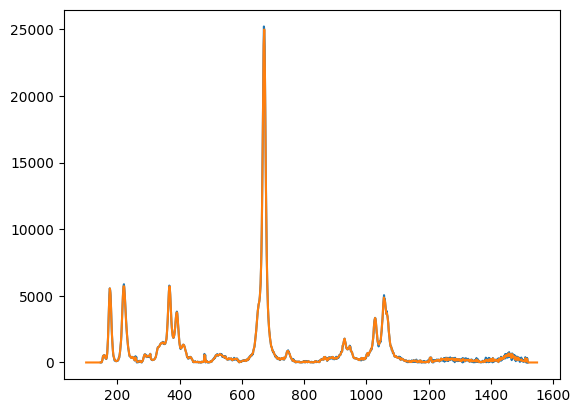

In [52]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(waven,intenn)
plt.plot(comn_waven,interpolate_spectrum(waven, intenn, comn_waven))
plt.show()

## the full dataset builder
### now we define a function to take in all the txt files and then do the similar parsing as above and build a ML ready dataset 

glob.glob finds all files matching a pattern. The loop builds two lists in parallel — rows (spectral data) and labels (mineral names). At the end, pd.DataFrame(rows, columns=common_wn) turns the list of arrays into a table where each column is a wavenumber.

In [ ]:
def datasetbuilder(folderpath, minerals_to_include, common_wn):
    rows = []
    labels = []
    # taking in all the txt files form the folder into one variable
    allfiles = glob.glob(os.path.join(folderpath,"*.txt"))
    for filepath in allfiles:
        mineral = os.path.basename(filepath).split("_")[0]
        if mineral not in minerals_to_include:
            continue
        waven,intenn = parse_rruff_file(filepath)
        resampled = interpolate_spectrum(waven,intenn,common_wn)
        rows.append(resampled)
        labels.append(mineral)
    df = pd.DataFrame(rows,columns=common_wn)
    df["label"] = labels
    return df

def parse_rruff_file(flpath):
    w = []
    i = []
    with open(flpath,"r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("##") or line=="":
                continue
            parts = line.split(",")
            if len(parts)>2:
                continue
            try:
                w.append(float(parts[0]))
                i.append(float(parts[1]))
            except ValueError:
                continue
    return np.array(w), np.array(i)
    
def interpolate_spectrum(wn,it,cwn):
    f = interp1d(wn,it,kind="linear",bounds_error=False,fill_value=0)
    return f(cwn)

minerals = ["Actinolite","Adamite","Aegirine","Aenigmatite","Akermanite","Albite"]
folderpath="C:/Users/68pup/pythstuff/mycodes/ML/rruff_new"
comnwn = np.arange(70,1700,2)
df1 = datasetbuilder(folderpath,minerals,comnwn)
    

In [81]:
df1

,70,72,74,76,78,80,82,84,86,88,...,1682,1684,1686,1688,1690,1692,1694,1696,1698,label
0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Actinolite
1,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Actinolite
2,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Actinolite
3,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Actinolite
4,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Actinolite
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5892.414911,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Albite
380,0.0,0.0,3.330453,241.705530,895.773286,1755.534811,2688.352379,3979.996023,4347.408661,4152.876856,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Albite
381,0.0,0.0,2825.628133,3514.440939,4570.131068,5720.121359,6870.971683,8338.540081,8852.219433,8772.126418,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Albite
382,0.0,0.0,2.264235,143.650015,581.512706,1263.334495,2193.428897,3460.473179,4239.765651,4292.200003,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Albite


## Now that the data is ready, we do somethings before getting to the Modeling

# Exploratory Data Analysis